# Regression from Scratch — Bank Marketing Dataset

**Target variable:** `balance` (average yearly balance in euros)  
**Dataset:** `bank_marketing_regression.csv`  
**Models:** Linear Regression · Polynomial Regression (implemented from scratch using NumPy)  
**Preprocessing:** sklearn (`LabelEncoder`, `StandardScaler`, `train_test_split`, metrics)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

## 2. Load Data

In [2]:
df = pd.read_csv('data/bank_marketing_regression.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (45211, 57)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,family_commitment,log_duration,log_campaign,age_squared,duration_squared,age_bin,customer_value,reachability,conversion_likelihood,financial_capacity
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,1,5.568345,0.693147,3364,68121,Q5,5,1,6,2
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,5.023881,0.693147,1936,22801,Q4,5,1,3,2
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,1,4.343805,0.693147,1089,5776,Q2,5,1,3,2


## 3. Exploratory Data Analysis

=== Dataset Info ===
Rows: 45,211  |  Columns: 57

Missing values: 3

=== Target: balance ===
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64


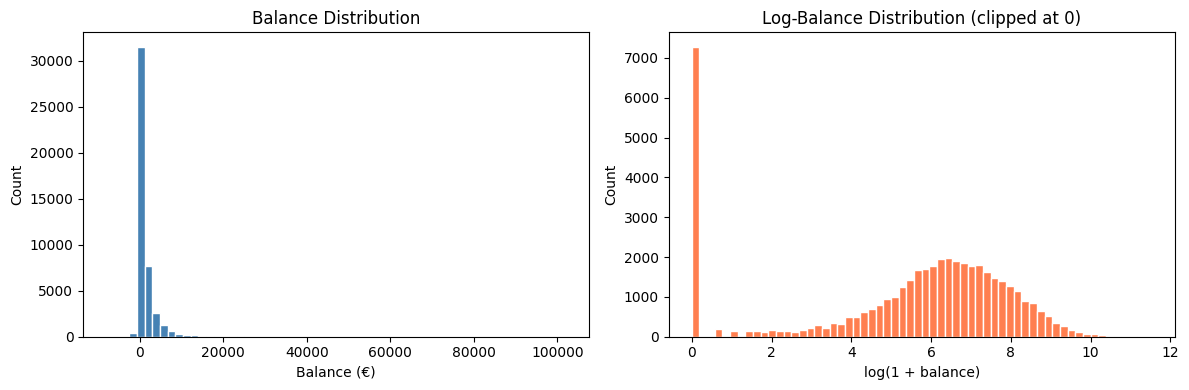

In [3]:
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("\n=== Target: balance ===")
print(df['balance'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['balance'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Balance Distribution')
axes[0].set_xlabel('Balance (€)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['balance'].clip(lower=0)), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log-Balance Distribution (clipped at 0)')
axes[1].set_xlabel('log(1 + balance)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Preprocessing

Standard preprocessing pipeline (sklearn):
1. **Drop** rows with missing values  
2. **Select** features (numeric + label-encoded categoricals)  
3. **`LabelEncoder`** — encode categorical columns  
4. **`StandardScaler`** — zero mean, unit variance  
5. **`train_test_split`** — 80 % train / 20 % test

In [4]:
df_clean = df.dropna().reset_index(drop=True)
print(f"After drop NA: {df_clean.shape[0]:,} rows")

TARGET = 'balance'

NUMERIC_FEATURES = [
    'age', 'duration', 'campaign', 'previous', 'pdays_clean',
    'day_of_week', 'month_num', 'has_debt', 'high_risk',
    'job_score', 'edu_score', 'socioeconomic_score',
    'was_contacted_before', 'prev_success', 'prev_failure',
    'family_commitment', 'end_of_month',
]

CATEGORICAL_FEATURES = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'poutcome',
]

df_encoded = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].copy()

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Features:", NUMERIC_FEATURES + CATEGORICAL_FEATURES)
print(f"\nEncoded DataFrame shape: {df_encoded.shape}")
df_encoded.head(3)

After drop NA: 45,208 rows
Features: ['age', 'duration', 'campaign', 'previous', 'pdays_clean', 'day_of_week', 'month_num', 'has_debt', 'high_risk', 'job_score', 'edu_score', 'socioeconomic_score', 'was_contacted_before', 'prev_success', 'prev_failure', 'family_commitment', 'end_of_month', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

Encoded DataFrame shape: (45208, 26)


,age,duration,campaign,previous,pdays_clean,day_of_week,month_num,has_debt,high_risk,job_score,...,end_of_month,job,marital,education,default,housing,loan,contact,poutcome,balance
0,58,261,1,0,999,5,5,1,1,4,...,0,4,1,2,0,1,0,2,3,2143
1,44,151,1,0,999,5,5,1,1,3,...,0,9,2,1,0,1,0,2,3,29
2,33,76,1,0,999,5,5,1,1,4,...,0,2,1,1,0,1,1,2,3,2


In [5]:
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X_raw = df_encoded[feature_cols].values.astype(float)
y     = df_encoded[TARGET].values.astype(float)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (36166, 25)  |  X_test: (9042, 25)
y_train: (36166,)  |  y_test: (9042,)


# Linear Regression

In [6]:
class LinearRegression:
    """
    Linear Regression implemented from scratch.

    Two fitting methods:
        'normal'  — closed-form Normal Equation:  θ = (XᵀX)⁻¹ Xᵀy
        'gradient' — Batch Gradient Descent
    """

    def __init__(self, method='normal', learning_rate=0.01, n_iterations=1000):
        self.method        = method
        self.learning_rate = learning_rate
        self.n_iterations  = n_iterations
        self.weights       = None
        self.bias          = None
        self.loss_history  = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights      = np.zeros(n_features)
        self.bias         = 0.0
        self.loss_history = []

        if self.method == 'normal':
            X_b       = np.c_[np.ones(n_samples), X]
            theta     = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
            self.bias    = theta[0]
            self.weights = theta[1:]

        elif self.method == 'gradient':
            for _ in range(self.n_iterations):
                y_pred = self._raw_predict(X)
                error  = y_pred - y
                dw = (2 / n_samples) * (X.T @ error)
                db = (2 / n_samples) * np.sum(error)
                self.weights -= self.learning_rate * dw
                self.bias    -= self.learning_rate * db
                self.loss_history.append(np.mean(error ** 2))

        else:
            raise ValueError(f"Unknown method '{self.method}'. Use 'normal' or 'gradient'.")

        return self

    def _raw_predict(self, X):
        return X @ self.weights + self.bias

    def predict(self, X):
        return self._raw_predict(X)

    def __repr__(self):
        return (f"LinearRegression(method='{self.method}', "
                f"lr={self.learning_rate}, n_iter={self.n_iterations})")

print("LinearRegression class defined.")

LinearRegression class defined.


## Simple Linear Regression

Train a model using only the single feature most correlated with the target variable.

In [7]:
feature_cols_list = NUMERIC_FEATURES + CATEGORICAL_FEATURES
corr_vals = np.array([
    abs(np.corrcoef(X_train[:, i], y_train)[0, 1])
    for i in range(X_train.shape[1])
])
best_idx     = int(np.argmax(corr_vals))
best_feature = feature_cols_list[best_idx]
print(f"Best single feature: '{best_feature}'  |corr| = {corr_vals[best_idx]:.4f}\n")

X_train_simple = X_train[:, [best_idx]]
X_test_simple  = X_test[:,  [best_idx]]

lr_simple = LinearRegression(method='normal')
lr_simple.fit(X_train_simple, y_train)

y_pred_train_simple = lr_simple.predict(X_train_simple)
y_pred_test_simple  = lr_simple.predict(X_test_simple)

metrics_simple = {
    'Train MSE':  mean_squared_error(y_train, y_pred_train_simple),
    'Test  MSE':  mean_squared_error(y_test,  y_pred_test_simple),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_simple)),
    'Test  RMSE': np.sqrt(mean_squared_error(y_test,  y_pred_test_simple)),
    'Train MAE':  mean_absolute_error(y_train, y_pred_train_simple),
    'Test  MAE':  mean_absolute_error(y_test,  y_pred_test_simple),
    'Train R\u00b2':   r2_score(y_train, y_pred_train_simple),
    'Test  R\u00b2':   r2_score(y_test,  y_pred_test_simple),
}

print(f"=== Simple Linear Regression (feature: '{best_feature}') ===")
for k, v in metrics_simple.items():
    print(f"  {k}: {v:>12.4f}")

Best single feature: 'age'  |corr| = 0.1020

=== Simple Linear Regression (feature: 'age') ===
  Train MSE: 9113840.6352
  Test  MSE: 9454887.9347
  Train RMSE:    3018.9138
  Test  RMSE:    3074.8801
  Train MAE:    1528.1308
  Test  MAE:    1545.1819
  Train R²:       0.0104
  Test  R²:       0.0062


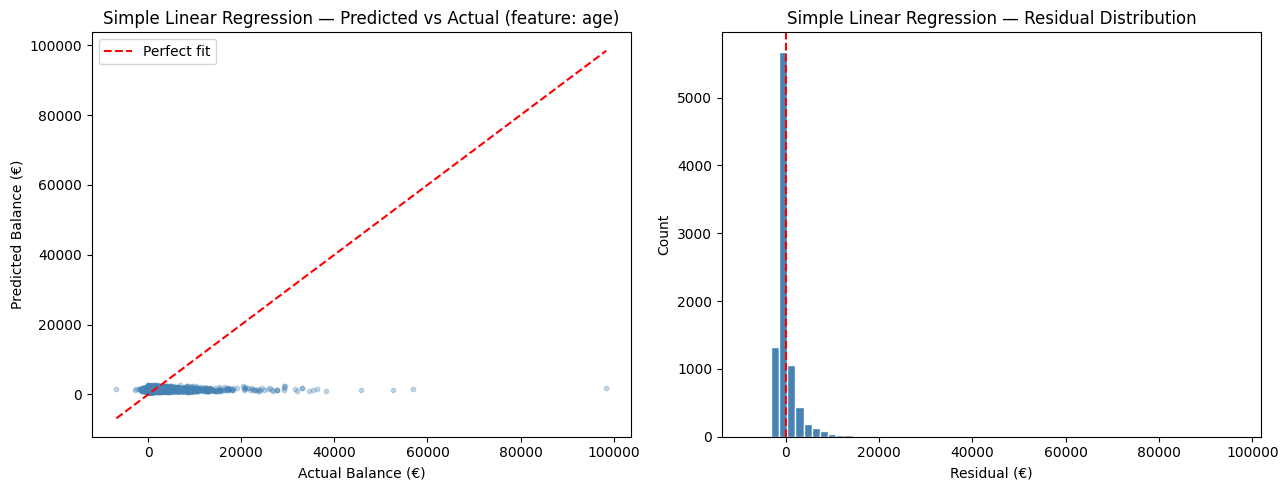

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test_simple, alpha=0.3, s=10, color='steelblue')
lim = [min(y_test.min(), y_pred_test_simple.min()),
       max(y_test.max(), y_pred_test_simple.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Balance (\u20ac)')
axes[0].set_ylabel('Predicted Balance (\u20ac)')
axes[0].set_title(f'Simple Linear Regression — Predicted vs Actual (feature: {best_feature})')
axes[0].legend()

residuals_simple = y_test - y_pred_test_simple
axes[1].hist(residuals_simple, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (\u20ac)')
axes[1].set_ylabel('Count')
axes[1].set_title('Simple Linear Regression — Residual Distribution')

plt.tight_layout()
plt.show()

## Multiple Regression

Train a model using all available features.

In [9]:
lr_model = LinearRegression(method='normal')
lr_model.fit(X_train, y_train)

y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr  = lr_model.predict(X_test)

metrics_lr = {
    'Train MSE':  mean_squared_error(y_train, y_pred_train_lr),
    'Test  MSE':  mean_squared_error(y_test,  y_pred_test_lr),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_lr)),
    'Test  RMSE': np.sqrt(mean_squared_error(y_test,  y_pred_test_lr)),
    'Train MAE':  mean_absolute_error(y_train, y_pred_train_lr),
    'Test  MAE':  mean_absolute_error(y_test,  y_pred_test_lr),
    'Train R²':   r2_score(y_train, y_pred_train_lr),
    'Test  R²':   r2_score(y_test,  y_pred_test_lr),
}

print("=== Multiple Regression (Normal Equation) ===")
for k, v in metrics_lr.items():
    print(f"  {k}: {v:>12.4f}")

=== Multiple Regression (Normal Equation) ===
  Train MSE: 8855959.0958
  Test  MSE: 9131029.0457
  Train RMSE:    2975.8964
  Test  RMSE:    3021.7593
  Train MAE:    1489.5496
  Test  MAE:    1504.2903
  Train R²:       0.0384
  Test  R²:       0.0402


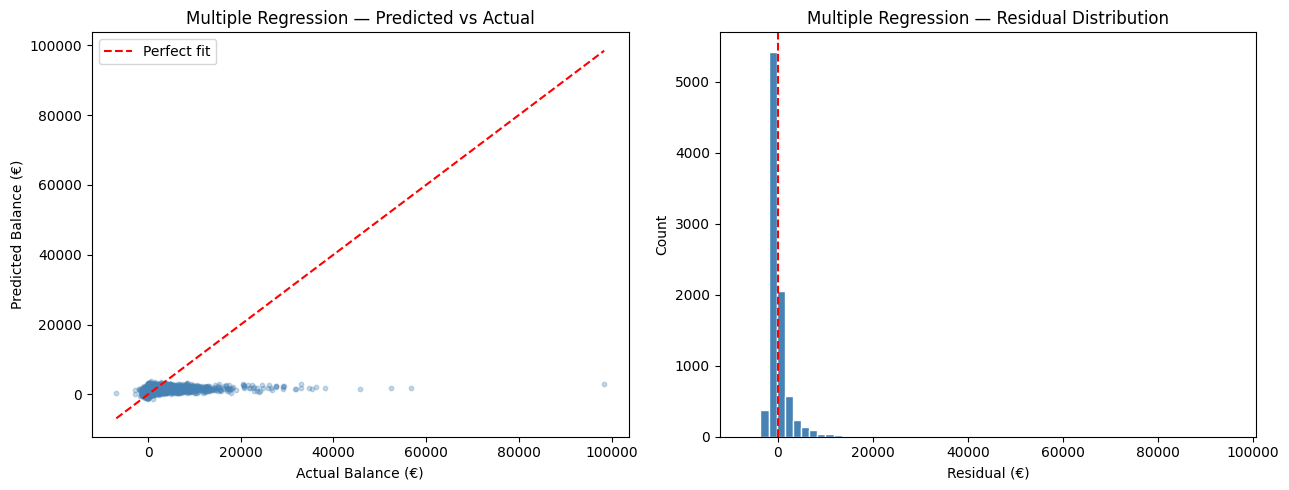

In [10]:
y_pred_test_lr = lr_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test_lr, alpha=0.3, s=10, color='steelblue')
lim = [min(y_test.min(), y_pred_test_lr.min()),
       max(y_test.max(), y_pred_test_lr.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Balance (€)')
axes[0].set_ylabel('Predicted Balance (€)')
axes[0].set_title('Multiple Regression — Predicted vs Actual')
axes[0].legend()

residuals_lr = y_test - y_pred_test_lr
axes[1].hist(residuals_lr, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (€)')
axes[1].set_ylabel('Count')
axes[1].set_title('Multiple Regression — Residual Distribution')

plt.tight_layout()
plt.show()

# Polynomial Regression

In [11]:
class PolynomialRegression:
    """
    Polynomial Regression implemented from scratch.

    Expands each feature  x  into  [x, x², x³, …, x^degree],
    then fits a LinearRegression on the expanded feature matrix.
    """

    def __init__(self, degree=2, method='normal',
                 learning_rate=0.01, n_iterations=1000):
        self.degree        = degree
        self.method        = method
        self.learning_rate = learning_rate
        self.n_iterations  = n_iterations
        self._lin_reg      = None

    def _poly_features(self, X):
        """Stack [X, X², …, X^degree] column-wise."""
        blocks = [X ** d for d in range(1, self.degree + 1)]
        return np.hstack(blocks)

    def fit(self, X, y):
        X_poly = self._poly_features(X)
        self._lin_reg = LinearRegression(
            method=self.method,
            learning_rate=self.learning_rate,
            n_iterations=self.n_iterations,
        )
        self._lin_reg.fit(X_poly, y)
        return self

    def predict(self, X):
        return self._lin_reg.predict(self._poly_features(X))

    def __repr__(self):
        return (f"PolynomialRegression(degree={self.degree}, "
                f"method='{self.method}')")

print("PolynomialRegression class defined.")

PolynomialRegression class defined.


In [12]:
pr_model = PolynomialRegression(degree=10, method='normal')
pr_model.fit(X_train, y_train)

y_pred_train_pr = pr_model.predict(X_train)
y_pred_test_pr  = pr_model.predict(X_test)

metrics_pr = {
    'Train MSE':  mean_squared_error(y_train, y_pred_train_pr),
    'Test  MSE':  mean_squared_error(y_test,  y_pred_test_pr),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_pr)),
    'Test  RMSE': np.sqrt(mean_squared_error(y_test,  y_pred_test_pr)),
    'Train MAE':  mean_absolute_error(y_train, y_pred_train_pr),
    'Test  MAE':  mean_absolute_error(y_test,  y_pred_test_pr),
    'Train R²':   r2_score(y_train, y_pred_train_pr),
    'Test  R²':   r2_score(y_test,  y_pred_test_pr),
}

print("=== Polynomial Regression  (degree=10, Normal Equation) ===")
for k, v in metrics_pr.items():
    print(f"  {k}: {v:>12.4f}")

=== Polynomial Regression  (degree=10, Normal Equation) ===
  Train MSE: 11052717.6272
  Test  MSE: 11420262.7004
  Train RMSE:    3324.5628
  Test  RMSE:    3379.3879
  Train MAE:    1410.1366
  Test  MAE:    1435.1735
  Train R²:      -0.2001
  Test  R²:      -0.2004


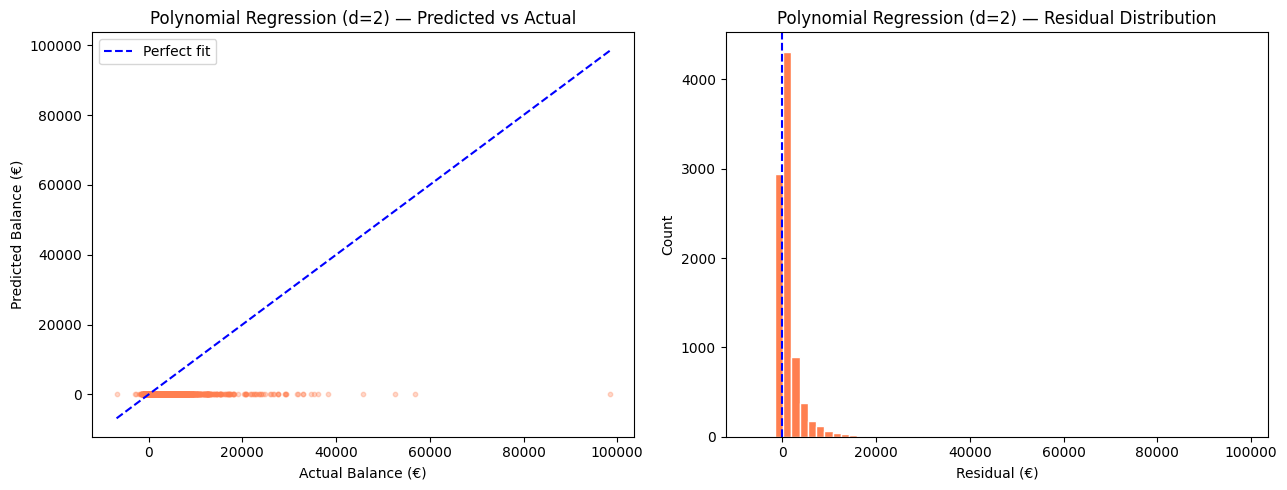

In [13]:
y_pred_test_pr = pr_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test_pr, alpha=0.3, s=10, color='coral')
lim = [min(y_test.min(), y_pred_test_pr.min()),
       max(y_test.max(), y_pred_test_pr.max())]
axes[0].plot(lim, lim, 'b--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Balance (€)')
axes[0].set_ylabel('Predicted Balance (€)')
axes[0].set_title('Polynomial Regression (d=2) — Predicted vs Actual')
axes[0].legend()

residuals_pr = y_test - y_pred_test_pr
axes[1].hist(residuals_pr, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='blue', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (€)')
axes[1].set_ylabel('Count')
axes[1].set_title('Polynomial Regression (d=2) — Residual Distribution')

plt.tight_layout()
plt.show()

## 5. Results Comparison

                      Model  Test RMSE  Test MAE  Test R²
   Simple Linear Regression  3074.8801 1545.1819   0.0062
        Multiple Regression  3021.7593 1504.2903   0.0402
Polynomial Regression (d=2)  3379.3879 1435.1735  -0.2004


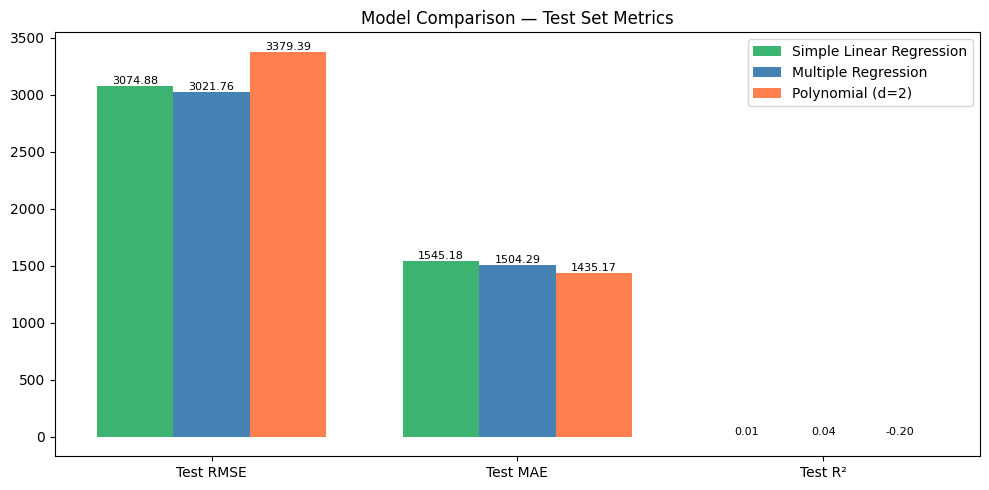

In [14]:
summary = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Regression',
        'Polynomial Regression (d=2)',
    ],
    'Test RMSE': [
        round(np.sqrt(mean_squared_error(y_test, y_pred_test_simple)), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_test_lr)),    4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_test_pr)),    4),
    ],
    'Test MAE': [
        round(mean_absolute_error(y_test, y_pred_test_simple), 4),
        round(mean_absolute_error(y_test, y_pred_test_lr),    4),
        round(mean_absolute_error(y_test, y_pred_test_pr),    4),
    ],
    'Test R²': [
        round(r2_score(y_test, y_pred_test_simple), 4),
        round(r2_score(y_test, y_pred_test_lr),    4),
        round(r2_score(y_test, y_pred_test_pr),    4),
    ],
})
print(summary.to_string(index=False))

metric_cols = ['Test RMSE', 'Test MAE', 'Test R²']
x = np.arange(len(metric_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars_s  = ax.bar(x - width,     summary.loc[0, metric_cols], width,
                  label='Simple Linear Regression', color='mediumseagreen')
bars_lr = ax.bar(x,              summary.loc[1, metric_cols], width,
                  label='Multiple Regression', color='steelblue')
bars_pr = ax.bar(x + width,      summary.loc[2, metric_cols], width,
                  label='Polynomial (d=2)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_title('Model Comparison — Test Set Metrics')
ax.legend()

for bar in list(bars_s) + list(bars_lr) + list(bars_pr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---

## สรุปผลการทดลอง

### 3.2.1 Simple Linear Regression

**Hyperparameters:** Feature = `age` (|corr| = 0.1020), Method = Normal Equation, Loss = MSE

โมเดลใช้ฟีเจอร์เพียงตัวเดียวที่มีค่าสหสัมพันธ์สูงสุดกับตัวแปรเป้าหมาย (`balance`) แต่เนื่องจากค่าสหสัมพันธ์ต่ำมาก ส่งผลให้ R² ในชุดทดสอบอยู่ที่เพียง **0.0062** สะท้อนว่าโมเดลแทบไม่สามารถอธิบายความแปรปรวนของ Balance ได้

| Metric | Train | Test |
|---|---|---|
| MSE | 9,113,840.64 | 9,454,887.93 |
| RMSE | 3,018.91 | 3,074.88 |
| MAE | 1,528.13 | 1,545.18 |
| R² | 0.0104 | 0.0062 |

---

### 3.2.2 Multiple Regression

**Hyperparameters:** Features = ทุกฟีเจอร์ (Numeric + Encoded Categorical), Method = Normal Equation, Loss = MSE

การเพิ่มจำนวนฟีเจอร์ช่วยให้ R² ในชุดทดสอบดีขึ้นเป็น **0.0402** และ RMSE ลดลงเหลือ **3,021.76 €** โมเดลไม่แสดงสัญญาณ Overfitting เนื่องจากค่า Train R² (0.0384) และ Test R² (0.0402) ใกล้เคียงกัน อย่างไรก็ตาม R² ยังต่ำ บ่งชี้ว่าความสัมพันธ์ในข้อมูลไม่เป็นเชิงเส้นตรง

| Metric | Train | Test |
|---|---|---|
| MSE | 8,855,959.10 | 9,131,029.05 |
| RMSE | 2,975.90 | 3,021.76 |
| MAE | 1,489.55 | 1,504.29 |
| R² | 0.0384 | 0.0402 |

---

### 3.2.3 Polynomial Regression

**Hyperparameters:** Degree = 10, Features = Polynomial Expansion ของทุกฟีเจอร์ [x, x², …, x¹⁰], Method = Normal Equation, Loss = MSE

โมเดลมีประสิทธิภาพต่ำที่สุดในทุก Metric โดยค่า R² ติดลบทั้งในชุดฝึก (-0.2001) และชุดทดสอบ (-0.2004) ซึ่งแย่กว่าการใช้ค่าเฉลี่ยอย่างเดียว สาเหตุหลักเกิดจาก Degree ที่สูงเกินไปทำให้ Feature Matrix มีขนาดใหญ่และเกิด Numerical Instability ใน Normal Equation (Ill-conditioned matrix)

| Metric | Train | Test |
|---|---|---|
| MSE | 11,052,717.63 | 11,420,262.70 |
| RMSE | 3,324.56 | 3,379.39 |
| MAE | 1,410.14 | 1,435.17 |
| R² | -0.2001 | -0.2004 |

---

### เปรียบเทียบโมเดล

| Model | Test RMSE | Test MAE | Test R² |
|---|---|---|---|
| Simple Linear Regression | 3,074.88 | 1,545.18 | 0.0062 |
| **Multiple Regression** | **3,021.76** | **1,504.29** | **0.0402** |
| Polynomial Regression (d=10) | 3,379.39 | 1,435.17 | -0.2004 |

**Multiple Regression** ให้ผลดีที่สุดในแง่ RMSE และ R² โดยรวมค่า R² ของทุกโมเดลต่ำ แสดงว่าข้อมูลชุดนี้มีความสัมพันธ์ที่ซับซ้อนและไม่เชิงเส้น ซึ่งโมเดล Linear-based ไม่สามารถจับ Pattern ได้อย่างมีประสิทธิภาพ